# ReAct Agent with LangGraph

**LangChain**의 `create_agent`를 활용하여 **ReAct** 기반의 AI 에이전트를 구축하는 방법을 다룹니다. 계산기 툴 예제를 통해 에이전트의 핵심 구성 요소와 상태 관리 방법을 학습합니다.

**🏆 핵심 내용**

*   **ReAct Agent**: Reasoning and Acting 프레임워크의 개념 및 동작 원리
*   **Prebuilt Agent**: 메모리, Human-in-the-loop, 스트리밍, 배포 등 주요 기능
*   **Tool Integration**: 계산기 툴 정의 및 에이전트 연동 실습
*   **Internal Structure**: 그래프(Graph), 상태(State), 메시지(Message) 흐름 분석
*   **Custom State**: `AgentState` 확장 및 Reducer 함수 구현
*   **State Injection**: `InjectedState`를 활용한 툴 내 상태 접근
*   **Command**: 툴 실행 결과를 통한 동적 상태 업데이트

## Prebuilt ReAct Agent 소개

![](./assets/agent_header.png)

이번 과정에서는 [Deep Agent](https://blog.langchain.com/deep-agents/)를 직접 구현해 봅니다. 

LangChain에서 제공하는 pre-built agent 추상화를 활용하면 복잡한 코드를 간결하게 작성할 수 있습니다. 

본 튜토리얼에서는 **Prebuilt ReAct Agent**의 주요 개념과 기능을 다룹니다.

추가적인 내용은 [Deep Agent 공식 블로그](https://blog.langchain.com/deep-agents/)에서 확인할 수 있습니다.

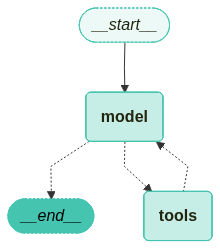

In [12]:
from deep_agents_from_scratch.SampleAgnetState import SampleAgnetState

workflow = SampleAgnetState()


workflow.show_graph()

In [13]:
# 에이전트에게 곱셈 질의 메시지 리스트 전달, 계산 요청 수행 및 결과 반환
from util.messages_in_jupyter import format_messages


result2 = workflow.invoke(
    {
        "messages": [
            {
                "role": "user",
                "content": "3.1 * 4.2는 얼마입니까?",
            }
        ],
    }
)

# 에이전트 응답 메시지 리스트를 보기 좋게 포맷팅하여 출력, 메시지 구조 확인
format_messages(result2["messages"])


🔄 Node: model 🔄
- - - - - - - - - - - - - - - - - - - - - - - - - 
================================== Ai Message ==================================
Tool Calls:
  calculator (call_y3MzaW66mIYnnl8Di6a5gMMH)
 Call ID: call_y3MzaW66mIYnnl8Di6a5gMMH
  Args:
    operation: multiply
    a: 3.1
    b: 4.2

🔄 Node: tools 🔄
- - - - - - - - - - - - - - - - - - - - - - - - - 
================================= Tool Message =================================
Name: calculator

13.020000000000001

🔄 Node: model 🔄
- - - - - - - - - - - - - - - - - - - - - - - - - 
================================== Ai Message ==================================

3.1 * 4.2는 13.02입니다.


╭─────────────────────────────────────────────────── 🧑 Human ────────────────────────────────────────────────────╮
│ 3.1 * 4.2는 얼마입니까?                                                                                         │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭───────────────────────────────────────────────────── 📝 AI ─────────────────────────────────────────────────────╮
│                                                                                                                 │
│                                                                                                                 │
│ 🔧 Tool Call: calculator                                                                                        │
│    Args: {                                                                                                      │
│   "operation": "multiply",                                                                                      │
│   "a": 3.1,                                                                                                     │
│   "b": 4.2                                                                                                      │
│ }                                                                                                               │
│    ID: call_y3MzaW66mIYnnl8Di6a5gMMH                                                                            │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭──────────────────────────────────────────────── 🔧 Tool Output ─────────────────────────────────────────────────╮
│ 13.020000000000001                                                                                              │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭───────────────────────────────────────────────────── 📝 AI ─────────────────────────────────────────────────────╮
│ 3.1 * 4.2는 13.02입니다.                                                                                        │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

In [14]:
from langchain_core.messages import messages_to_dict

messages_to_dict(result["messages"])

[{'type': 'human',
  'data': {'content': '3.1 * 4.2는 얼마입니까?',
   'additional_kwargs': {},
   'response_metadata': {},
   'type': 'human',
   'name': None,
   'id': 'cd572f30-fe64-4f7a-84cc-4884baf86d01'}},
 {'type': 'ai',
  'data': {'content': '',
   'additional_kwargs': {'refusal': None},
   'response_metadata': {'token_usage': {'completion_tokens': 26,
     'prompt_tokens': 192,
     'total_tokens': 218,
     'completion_tokens_details': {'accepted_prediction_tokens': 0,
      'audio_tokens': 0,
      'reasoning_tokens': 0,
      'rejected_prediction_tokens': 0},
     'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}},
    'model_provider': 'openai',
    'model_name': 'gpt-4o-mini-2024-07-18',
    'system_fingerprint': 'fp_84283cb50c',
    'id': 'chatcmpl-Dh47TJaZe61BiLIg7bm75p6DfRJ2E',
    'service_tier': 'default',
    'finish_reason': 'tool_calls',
    'logprobs': None},
   'type': 'ai',
   'name': None,
   'id': 'lc_run--019e3dfa-db8a-7bb1-9fb3-b0b540b10bdd-0',
   

이번에는 두 개의 툴 호출이 동시에 이루어지는 예시를 살펴보겠습니다. 이 경우, `tool node`는 각 툴 호출을 병렬로 실행하여 결과를 반환합니다.  

이처럼 복수의 툴 호출이 병렬로 처리되는 구조를 이해하면, 에이전트가 여러 작업을 효율적으로 수행하는 방식에 대해 더욱 깊이 있게 학습할 수 있습니다.

In [16]:
# 복수 연산 질의 메시지 리스트를 에이전트에게 전달하여 병렬 계산 요청 수행
result3 = workflow.invoke(
    {
        "messages": [
            {
                "role": "user",
                "content": "3.1 * 4.2 + 5.5 * 6.5는 얼마입니까?",
            }
        ],
    }
)

# 에이전트의 응답 메시지 리스트를 보기 좋게 포맷팅하여 출력
format_messages(result3["messages"])


🔄 Node: model 🔄
- - - - - - - - - - - - - - - - - - - - - - - - - 
================================== Ai Message ==================================
Tool Calls:
  calculator (call_mFNPsS1UGPY6SeRWPAB3EvTS)
 Call ID: call_mFNPsS1UGPY6SeRWPAB3EvTS
  Args:
    operation: multiply
    a: 3.1
    b: 4.2
  calculator (call_vFahnM2vnYas3xb63mWiXEgv)
 Call ID: call_vFahnM2vnYas3xb63mWiXEgv
  Args:
    operation: multiply
    a: 5.5
    b: 6.5

🔄 Node: tools 🔄
- - - - - - - - - - - - - - - - - - - - - - - - - 
================================= Tool Message =================================
Name: calculator

13.020000000000001

🔄 Node: tools 🔄
- - - - - - - - - - - - - - - - - - - - - - - - - 
================================= Tool Message =================================
Name: calculator

35.75

🔄 Node: model 🔄
- - - - - - - - - - - - - - - - - - - - - - - - - 
================================== Ai Message ==================================
Tool Calls:
  calculator (call_kwwJvtu8WaYrgiL821n5Sc

╭─────────────────────────────────────────────────── 🧑 Human ────────────────────────────────────────────────────╮
│ 3.1 * 4.2 + 5.5 * 6.5는 얼마입니까?                                                                             │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭───────────────────────────────────────────────────── 📝 AI ─────────────────────────────────────────────────────╮
│                                                                                                                 │
│                                                                                                                 │
│ 🔧 Tool Call: calculator                                                                                        │
│    Args: {                                                                                                      │
│   "operation": "multiply",                                                                                      │
│   "a": 3.1,                                                                                                     │
│   "b": 4.2                                                                                                      │
│ }                                                                                                               │
│    ID: call_mFNPsS1UGPY6SeRWPAB3EvTS                                                                            │
│                                                                                                                 │
│ 🔧 Tool Call: calculator                                                                                        │
│    Args: {                                                                                                      │
│   "operation": "multiply",                                                                                      │
│   "a": 5.5,                                                                                                     │
│   "b": 6.5                                                                                                      │
│ }                                                                                                               │
│    ID: call_vFahnM2vnYas3xb63mWiXEgv                                                                            │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭──────────────────────────────────────────────── 🔧 Tool Output ─────────────────────────────────────────────────╮
│ 13.020000000000001                                                                                              │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭──────────────────────────────────────────────── 🔧 Tool Output ─────────────────────────────────────────────────╮
│ 35.75                                                                                                           │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭───────────────────────────────────────────────────── 📝 AI ─────────────────────────────────────────────────────╮
│                                                                                                                 │
│                                                                                                                 │
│ 🔧 Tool Call: calculator                                                                                        │
│    Args: {                                                                                                      │
│   "operation": "add",                                                                                           │
│   "a": 13.020000000000001,                                                                                      │
│   "b": 35.75                                                                                                    │
│ }                                                                                                               │
│    ID: call_kwwJvtu8WaYrgiL821n5ScB1                                                                            │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭──────────────────────────────────────────────── 🔧 Tool Output ─────────────────────────────────────────────────╮
│ 48.77                                                                                                           │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭───────────────────────────────────────────────────── 📝 AI ─────────────────────────────────────────────────────╮
│ 3.1 * 4.2 + 5.5 * 6.5는 48.77입니다.                                                                            │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

In [13]:
# 사용자에게 에이전트가 직접 예시를 생성하도록 질의 메시지 전달 및 결과 반환
result4 = agent.invoke(
    {
        "messages": [
            {
                "role": "user",
                "content": "자신만의 예시를 만들어 보시겠습니까?",
            }
        ],
    }
)

# 에이전트의 응답 메시지 리스트를 보기 좋게 포맷팅하여 출력
format_messages(result4["messages"])

╭─────────────────────────────────────────────────── 🧑 Human ────────────────────────────────────────────────────╮
│ 자신만의 예시를 만들어 보시겠습니까?                                                                            │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭───────────────────────────────────────────────────── 📝 AI ─────────────────────────────────────────────────────╮
│ 네, 기꺼이 예시를 만들어 드리겠습니다!                                                                          │
│                                                                                                                 │
│ 예를 들어, 다음과 같은 산술 문제를 풀어보겠습니다:                                                              │
│                                                                                                                 │
│ **문제: 한 학생이 책을 사러 가서 15,000원짜리 책 3권을 샀습니다. 그리고 5,000원짜리 펜 2개를 샀습니다. 총       │
│ 얼마를 썼을까요?**                                                                                              │
│                                                                                                                 │
│ 이 문제를 단계별로 풀어보겠습니다:                                                                              │
│                                                                                                                 │
│ 1단계: 책에 쓴 돈 계산 (15,000 × 3)                                                                             │
│ 2단계: 펜에 쓴 돈 계산 (5,000 × 2)                                                                              │
│ 3단계: 총액 계산 (책 비용 + 펜 비용)                                                                            │
│                                                                                                                 │
│ 🔧 Tool Call: calculator_wstate                                                                                 │
│    Args: {                                                                                                      │
│   "operation": "multiply",                                                                                      │
│   "a": 15000,                                                                                                   │
│   "b": 3                                                                                                        │
│ }                                                                                                               │
│    ID: toolu_01GkLFqSaGq1scUkWJ55ra4P                                                                           │
│                                                                                                                 │
│ 🔧 Tool Call: calculator_wstate                                                                                 │
│    Args: {                                                                                                      │
│   "operation": "multiply",                                                                                      │
│   "a": 5000,                                                                                                    │
│   "b": 2                                                                                                        │
│ }                                                                                                               │
│    ID: toolu_01CiL7utndw5eA7NSiugaatZ                                                                           │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭──────────────────────────────────────────────── 🔧 Tool Output ─────────────────────────────────────────────────╮
│ 45000                                                                                                           │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭──────────────────────────────────────────────── 🔧 Tool Output ─────────────────────────────────────────────────╮
│ 10000                                                                                                           │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭───────────────────────────────────────────────────── 📝 AI ─────────────────────────────────────────────────────╮
│ 이제 총액을 계산합니다:                                                                                         │
│                                                                                                                 │
│ 🔧 Tool Call: calculator_wstate                                                                                 │
│    Args: {                                                                                                      │
│   "operation": "add",                                                                                           │
│   "a": 45000,                                                                                                   │
│   "b": 10000                                                                                                    │
│ }                                                                                                               │
│    ID: toolu_01KHfiGnh2iMyxrXqUNApUfs                                                                           │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭──────────────────────────────────────────────── 🔧 Tool Output ─────────────────────────────────────────────────╮
│ 55000                                                                                                           │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭───────────────────────────────────────────────────── 📝 AI ─────────────────────────────────────────────────────╮
│ **답: 학생은 총 55,000원을 썼습니다.**                                                                          │
│                                                                                                                 │
│ - 책 3권: 45,000원                                                                                              │
│ - 펜 2개: 10,000원                                                                                              │
│ - 총합: 55,000원                                                                                                │
│                                                                                                                 │
│ 이런 식으로 계산기를 사용하여 실생활의 산술 문제를 풀 수 있습니다!                                              │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯